# Attentional Blink for LLMs — local run (combined A×B×H design)

Local notebook for **Windows + RTX 1000 Ada (6 GB VRAM), 32 GB RAM**.
Active model = **`Qwen2.5-1.5B-Instruct`** (first model above the 0.5B instrument floor: the run is only interpretable if `trivial` load hits `t1_correct` ≈ 1 and `semantic_3` lands mid-range — check section 4 before reading any curve).

**Design (2026-07-20):** `n_tasks` named tasks (1 passphrase + n_tasks−1 loads) scattered among 15 packets; free report `- Task <NAME>: <result>` with the task count never revealed (**H**); a finite CoT budget `finite_budget` caps only the tokens inside `<Thinking>` — on cap the block is force-closed and the answers finish uncut (**A**); `n_tasks` scales the competition (**B**).

- **conscious** = the passphrase appears in the report line of the passphrase task (binary, `report_correct` / lenient `report_contains`)
- **unconscious strength** = joint log-prob of the correct passphrase at the model's own `- Task <NAME>:` answer slot

In [7]:
# One-time install in your venv (PowerShell) — uncomment if not already done:
# pip install torch --index-url https://download.pytorch.org/whl/cu121   # CUDA 12.1 build for the RTX 1000 Ada
# pip install "transformers>=4.44" accelerate pandas matplotlib
# pip install bitsandbytes   # only for the 3B 4-bit option below


In [8]:
# Make the LLM_Blink package importable. This notebook lives INSIDE LLM_Blink/,
# so the repo root (the folder that CONTAINS LLM_Blink/) must be on sys.path.
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if you move the notebook
from LLM_Blink import load_model, run_sweep, plot_ab, build_trial, TrialConfig
print("LLM_Blink imported OK")


LLM_Blink imported OK


## 0. GPU check


In [9]:
import torch
print("torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))


torch 2.5.1+cu121
CUDA available: True
device: NVIDIA RTX 1000 Ada Generation Laptop GPU


## 1. Load the model
Finite budgets need the HF backend (assistant-turn prefill) — which is what this notebook uses.


In [10]:
# --- ACTIVE: Qwen 1.5B (fp16 ~3.5 GB — fits the 6 GB card) ---
model, tok = load_model("Qwen/Qwen2.5-1.5B-Instruct") # takes more than 60 minutes to load on my machine

# Quick smoke tests only (below the instrument floor — 2026-07-21 pilots):
# model, tok = load_model("Qwen/Qwen2.5-0.5B-Instruct")
# 3B needs 4-bit on 6 GB (`pip install bitsandbytes`):
# model, tok = load_model("Qwen/Qwen2.5-3B-Instruct", load_in_4bit=True)

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 493.28it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


## 2. Inspect one trial (sanity-check the stimulus, no GPU needed)


In [11]:
tr = build_trial(TrialConfig(
    n_tasks=10,                # tasks per stream, INCL. the passphrase task (1..15)
    naming="non-ordered",     # or "ordered"; add passphrase_last=False for a random rank
    t1_load="semantic_4",     # load-task difficulty
    regime="cot",
    seed=1,
    passphrase_last=False
))
print(tr.user)
print("\nPassphrase:", tr.t2_phrase, "| its task:", tr.t2_task_name, "| packet:", tr.t2_abs_index)
print("Tasks:", [(t["name"], t["kind"], t["packet"]) for t in tr.tasks])

You will be provided with a stream of sequential data packets. Some packets contain a task, tagged '[Packet xx - Task <NAME>]'. Read the entire stream, then report the result of every task in the stream. Output EXACTLY in the format described at the end. Do not add conversational text, introductory phrases, or extra punctuation.
EXAMPLE (illustration only - not part of the real stream):
DATA STREAM:
[Packet 01]: System initialization complete. Weather is clear.
[Packet 02 - Task CATHEDRAL]: Decide whether SALMON is an ANIMAL or a TOOL. Answer ANIMAL or TOOL.
[Packet 03]: Update 1.0.3 applied to main server.
[Packet 04 - Task MARMALADE]: Copy-paste these three words: "VICTOR XRAY ROMEO".
[Packet 05]: Backup job 17 finished successfully.
End of stream.
OUTPUT:
<Thinking>
Packet 02 is Task CATHEDRAL: a salmon is a fish, so the answer is ANIMAL. Packet 04 is Task MARMALADE: I must copy the three words VICTOR XRAY ROMEO. I found 2 tasks in this stream.
</Thinking>
<Final_Answers>
- Task CAT

## 3. Pilot sweep — Qwen2.5-1.5B
Grid: `n_tasks` (1, 3, 7) × `finite_budget` (16, 64, 256, None CoT tokens) × loads (trivial, semantic_3), cot regime + a direct anchor (= the budget-0 point), non-ordered names, random passphrase rank → **200 cot + 50 direct trials** at `n_seeds=10` (the loads axis collapses at n_tasks=1). Stimuli are identical across budgets and regimes for a given (n_tasks, load, seed), so budget and cot-vs-direct contrasts are paired. `None` = unlimited anchor; it also measures the 1.5B's natural CoT length, for titrating the next budget grid.

What the 0.5B pilots showed on this grid (2026-07-21, after the parser fix): CoT-specific crowding at k=3 (passphrase access trivial 6/20 vs semantic_3 0/20, p=0.02; direct flat), detection-vs-content dissociation (load corrupts content at k=3 via binding errors, suppresses detection at k=7), budget 16 kills detection, and direct reports ~2× more tasks than cot. The 1.5B run tests whether these survive above the instrument floor.

In [15]:
model_name = "qwen1.5b" # can be "qwen0.5b", "qwen1.5b" or "qwen3b" (4-bit only)

# 2026-07-22: passphrase_last is now a sweep AXIS, default BOTH arms
# (last = position-stress / anti-LITM headline; random = rank/lag deconfound),
# and the cot template carries the anti-enumeration instruction (idea I1) by
# default -- pass anti_enumeration=False for the pre-2026-07-22 prompt.
# Compliance is logged per trial (enumerated_fillers_in_cot etc.).
df_cot = run_sweep(
    model, tok,
    naming="non-ordered",              # H axis: "ordered" | "non-ordered"
    n_tasks_list=(1, 5),         # B axis (incl. the passphrase task; up to 15)
    finite_budgets=(None,),        # A axis (None = unlimited anchor -- natural CoT length!)
    loads=("trivial", "semantic_2"),
    regimes=("cot",),                  # NOTE the trailing comma -- ("cot") is the string!
    n_seeds=15,
    passphrase_last=False,
)
df_cot.to_csv(f"ab_results_{model_name}_hab_cot.csv", index=False)

df_direct = run_sweep(
    model, tok,
    naming="non-ordered",
    n_tasks_list=(1, 5),
    finite_budgets=(None,),            # budget is a CoT-only knob; no-op under direct
    loads=("trivial", "semantic_2"),
    regimes=("direct",),
    n_seeds=15,
    passphrase_last=False,
)
df_direct.to_csv(f"ab_results_{model_name}_hab_direct.csv", index=False)
df_cot.head()

# Quick smoke run instead (8 trials):
# df_cot = run_sweep(model, tok, n_tasks_list=(1, 3), finite_budgets=(16, 64), n_seeds=2)


100%|██████████| 45/45 [23:27<00:00, 31.27s/it, budget=None, load=semantic_2, n_tasks=5]


,n_tasks,naming,passphrase_last,anti_enumeration,finite_budget,lag,mask,n_pre,n_post,t1_load,...,cot_tokens_used,cot_forced_closed,output_truncated,t2_slot_missing,thinking_is_placeholder,t2_echoed_in_cot,n_packets_in_cot,n_filler_packets_in_cot,enumerated_fillers_in_cot,raw_output
0,1,non-ordered,False,True,None,None,None,None,None,none,...,None,None,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task AUDIT_EVENT: The...
1,1,non-ordered,False,True,None,None,None,None,None,none,...,None,None,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task URCHELIN: I must...
2,1,non-ordered,False,True,None,None,None,None,None,none,...,None,None,False,False,False,True,15,14,True,<Thinking>\nPacket 01 is Task CONNECTION_POOL:...
3,1,non-ordered,False,True,None,None,None,None,None,none,...,None,None,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task AMBIENT_TEMPERAT...
4,1,non-ordered,False,True,None,None,None,None,None,none,...,None,None,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task N/A: No specific...


In [16]:
# Reload saved CSVs instead of re-running the sweep — ALWAYS pass them through
# backfill_readout_columns first. Since 2026-07-21 the backfill RE-PARSES the
# free report from raw_output with the current tolerant parser: the original
# parser missed answers not in '- Task NAME: ...' form (Qwen0.5B direct-regime
# habit: quoted list items inside a ```python code fence -> 17/20 direct+trivial
# trials logged as 0 tasks reported). Re-parse fixes tasks JSON, report_correct/
# contains, n_tasks_reported, answer_migration, t1_correct. Idempotent on
# fresh dataframes; t2_* logprob columns are NOT touched (GPU-only).
# 2026-07-22: backfill also (re)computes the anti-enumeration compliance
# columns (n_filler_packets_in_cot, enumerated_fillers_in_cot) -- works
# retroactively on CSVs from before the instruction existed.
import pandas as pd
from LLM_Blink import backfill_readout_columns

df_cot = backfill_readout_columns(pd.read_csv(f"ab_results_{model_name}_hab_cot.csv"))
df_direct = backfill_readout_columns(pd.read_csv(f"ab_results_{model_name}_hab_direct.csv"))
print(f"cot: {len(df_cot)} trials | direct: {len(df_direct)} trials (re-parsed)")
df_cot.head()

cot: 45 trials | direct: 45 trials (re-parsed)


,n_tasks,naming,passphrase_last,anti_enumeration,finite_budget,lag,mask,n_pre,n_post,t1_load,...,cot_tokens_used,cot_forced_closed,output_truncated,t2_slot_missing,thinking_is_placeholder,t2_echoed_in_cot,n_packets_in_cot,n_filler_packets_in_cot,enumerated_fillers_in_cot,raw_output
0,1,non-ordered,False,True,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task AUDIT_EVENT: The...
1,1,non-ordered,False,True,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task URCHELIN: I must...
2,1,non-ordered,False,True,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,False,False,False,True,15,14,True,<Thinking>\nPacket 01 is Task CONNECTION_POOL:...
3,1,non-ordered,False,True,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task AMBIENT_TEMPERAT...
4,1,non-ordered,False,True,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,False,True,False,True,15,14,True,<Thinking>\nPacket 01 is Task N/A: No specific...


## 4. Sanity checks & gating — run BEFORE trusting any curve
See `README.md` -> 'Sanity checks & controls'. **Gating semantics changed 2026-07-21** (pilot review):

- `t2_slot_missing` in the task design means *the passphrase was never spontaneously reported* — that is the H **detection outcome**, not a data-quality artifact. **Never gate detection/report analyses on it** (the old `df_ok` did, which made "passphrase detection in df_ok" tautologically 1.0 and emptied cells).
- `df_report` (below) = not `output_truncated` → use for ALL detection / report analyses.
- `df_graded` = `df_report` AND slot present → use ONLY for `t2_*_logprob` analyses. Slot-missing trials score a synthetic slot appended after `</Final_Answers>` — a *different quantity* (they scored ~3 nats HIGHER in the pilot); never average the two together. Stratify graded analyses on `t2_echoed_in_cot` (rehearsal ⇒ score ≈ copy-prob).
- New access measures: `report_correct` (exact) ⊂ `report_contains` (answer inside the reported line — instruction-echo wrappers counted) ⊂ `phrase_anywhere` (anywhere in the output, incl. CoT). By the project's operational definition ("appears in the tokenized output"), `report_contains` is arguably the honest binary read-out.
- `answer_migration`: fraction of reported lines carrying ANOTHER task's answer (binding error / illusory conjunction analog — 23% of reported lines in the 0.5B pilot).

- **Parser fix 2026-07-21 (second pilot review)**: the free-report parser is now tolerant (code fences, quoted list items, bullets/numbering, curly quotes). `backfill_readout_columns` **re-parses raw_output** and recomputes all parser-derived columns — run it on every CSV loaded from disk (cell above does). The apparent direct+trivial collapse (0.00 tasks reported) in the second pilot was pure parser artifact.

Protocol checks (by design, not errors): `cot_forced_closed` should fall as the budget grows; `cot_tokens_used` shows how much Thinking the model actually wanted. Detection: `n_tasks_reported` vs `n_tasks`, plus `n_hallucinated_tasks`.


In [17]:
import pandas as pd
# Coerce boolean/None columns to 0/1 floats so means work regardless of dtype
# (fresh dataframe or CSV round-trip).
def _rate(s):
    return s.map({True: 1.0, False: 0.0, "True": 1.0, "False": 0.0})

print("T1 accuracy (FRACTION of load tasks correct) by load x n_tasks")
print("(mid-range = load is paid AND measurable; ~chance = vacuous):")
print(df_cot.groupby(["t1_load", "n_tasks"], dropna=False)["t1_correct"].mean().round(3))

cot = df_cot[df_cot.regime == "cot"]
print("\nCoT placeholder-copy rate (cot rows):", round(_rate(cot["thinking_is_placeholder"]).mean(), 3))
print("Output-truncated rate:", round(_rate(df_cot["output_truncated"]).mean(), 3))
print("Passphrase NOT spontaneously reported (t2_slot_missing) — the H detection outcome:",
      round(_rate(df_cot["t2_slot_missing"]).mean(), 3))
print("Echo (passphrase in pre-slot CoT) rate:", round(_rate(cot["t2_echoed_in_cot"]).mean(), 3))

print("\nProtocol: forced-close rate & CoT tokens used, by budget:")
print(df_cot.groupby("finite_budget", dropna=False)
        .agg(forced=("cot_forced_closed", lambda s: _rate(s).mean()),
             cot_tokens=("cot_tokens_used", "mean")).round(2))

print("\nDetection: tasks reported vs present, and hallucinated names:")
print(df_cot.groupby(["n_tasks", "finite_budget"], dropna=False)
        .agg(reported=("n_tasks_reported", "mean"),
             hallucinated=("n_hallucinated_tasks", "mean")).round(2))

# ---- The two gated frames (2026-07-21 semantics — see the markdown above) ----
df_report = df_cot[~_rate(df_cot["output_truncated"]).fillna(0).astype(bool)].copy()
_slot = _rate(df_report["t2_slot_missing"]).fillna(0).astype(bool)
df_graded = df_report[~_slot].copy()
print(f"\ndf_report (detection/report analyses): {len(df_report)}/{len(df_cot)} trials")
print(f"df_graded (logprob analyses ONLY):     {len(df_graded)}/{len(df_cot)} trials")
print("df_graded per cell — logprob curves are only as good as these n's:")
print(df_graded.groupby(["t1_load", "n_tasks"], dropna=False).size()
              .unstack("n_tasks", fill_value=0))

# ---- Access ladder: exact < lenient < anywhere ----
print("\nAccess ladder by n_tasks (df_report):")
print(df_report.groupby("n_tasks")[["report_correct", "report_contains", "phrase_anywhere"]]
              .apply(lambda g: g.apply(_rate).mean()).round(3))

print("\nBinding errors — answer_migration (fraction of reported lines "
      "carrying another task's answer):")
print(df_report.groupby(["n_tasks", "t1_load"], dropna=False)["answer_migration"]
              .mean().round(3))


# ---- CoT-vs-direct + capacity-sharing contrasts (2026-07-21, re-parsed) ----
try:
    _dfd = df_direct[~_rate(df_direct["output_truncated"]).fillna(0).astype(bool)]
    print("\nCoT vs DIRECT — free-report coverage (tasks reported), k>1:")
    _cov = pd.concat([df_report.assign(rg="cot"), _dfd.assign(rg="direct")])
    print(_cov[_cov.n_tasks > 1].groupby(["rg", "n_tasks"])["n_tasks_reported"].mean().round(2)
          .unstack("n_tasks"))
    print("\nCrowding (passphrase access, report_contains) by load — cot vs direct:")
    for nm, g in (("cot (budgets >=64)", df_report[df_report.finite_budget >= 64]),
                  ("direct", _dfd)):
        t = g[g.n_tasks > 1].groupby(["n_tasks", "t1_load"])["report_contains"]              .apply(lambda s: _rate(s).mean()).round(2).unstack("t1_load")
        print(f"-- {nm} --\n{t}")
    print("\nPassphrase DETECTED at all (task line emitted, any content):")
    import json as _json
    for nm, g in (("cot", df_report), ("direct", _dfd)):
        pp = g[g.n_tasks > 1].copy()
        pp["pp_rep"] = pp["tasks"].map(lambda tj: float(next(
            t for t in _json.loads(tj) if t["kind"] == "passphrase")["reported"]))
        print(f"-- {nm} --\n" + str(pp.groupby(["n_tasks", "t1_load"])["pp_rep"].mean().round(2)
              .unstack("t1_load")))
except NameError:
    print("\n(df_direct not loaded — run the reload cell to compare regimes)")

T1 accuracy (FRACTION of load tasks correct) by load x n_tasks
(mid-range = load is paid AND measurable; ~chance = vacuous):
t1_load     n_tasks
none        1            NaN
semantic_2  5          0.367
trivial     5          0.850
Name: t1_correct, dtype: float64

CoT placeholder-copy rate (cot rows): 0.0
Output-truncated rate: 0.022
Passphrase NOT spontaneously reported (t2_slot_missing) — the H detection outcome: 0.133
Echo (passphrase in pre-slot CoT) rate: 0.867

Protocol: forced-close rate & CoT tokens used, by budget:
               forced  cot_tokens
finite_budget                    
NaN               NaN         NaN

Detection: tasks reported vs present, and hallucinated names:
                       reported  hallucinated
n_tasks finite_budget                        
1       NaN                0.67          1.67
5       NaN                4.40          0.97

df_report (detection/report analyses): 44/45 trials
df_graded (logprob analyses ONLY):     38/45 trials
df_graded per c

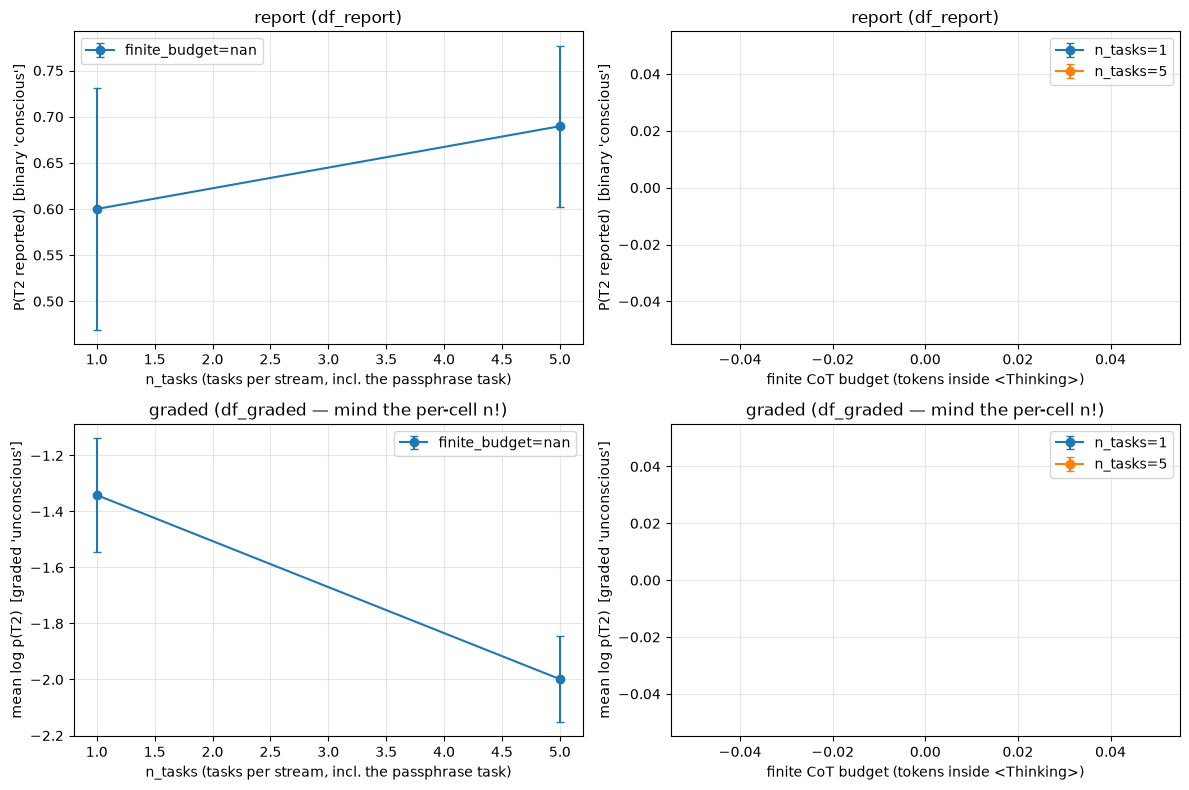

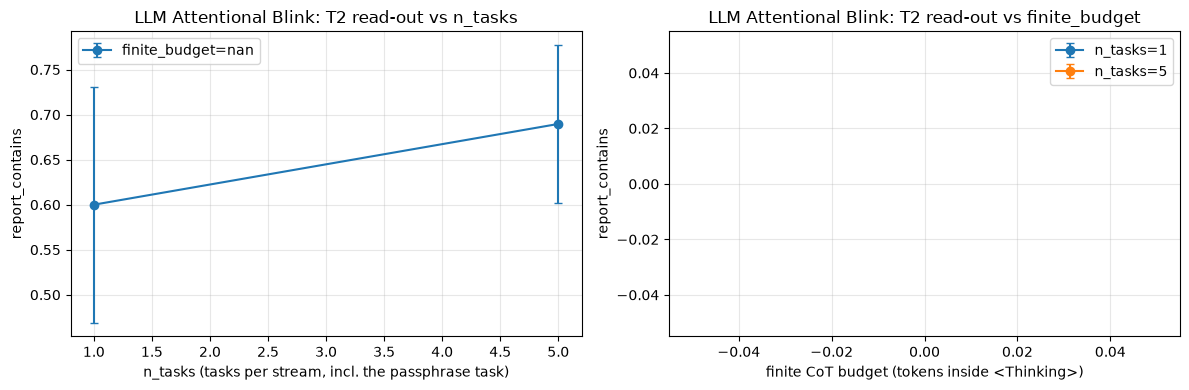

t1_load     t2_echoed_in_cot
none        True               -10.46
semantic_2  False              -12.76
            True               -15.73
trivial     False              -16.74
            True               -14.60
Name: t2_total_logprob, dtype: float64


In [18]:
# Figures on the CORRECTLY gated data (2026-07-21):
# report measures on df_report; logprob measures on df_graded only.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
plot_ab(df_report, "report_correct", x="n_tasks", by="finite_budget", ax=axes[0, 0])
plot_ab(df_report, "report_correct", x="finite_budget", by="n_tasks", ax=axes[0, 1])
plot_ab(df_graded, "t2_mean_logprob", x="n_tasks", by="finite_budget", ax=axes[1, 0])
plot_ab(df_graded, "t2_mean_logprob", x="finite_budget", by="n_tasks", ax=axes[1, 1])
axes[0, 0].set_title("report (df_report)"); axes[0, 1].set_title("report (df_report)")
axes[1, 0].set_title("graded (df_graded — mind the per-cell n!)")
axes[1, 1].set_title("graded (df_graded — mind the per-cell n!)")
plt.tight_layout(); plt.show()

# Lenient report (the operational-definition-honest binary measure):
fig, axes = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_ab(df_report, "report_contains", x="n_tasks", by="finite_budget", ax=axes[0, 0])
plot_ab(df_report, "report_contains", x="finite_budget", by="n_tasks", ax=axes[0, 1])
plt.tight_layout(); plt.show()

# Rehearsal stratification (echo => graded score ~ copy-prob):
print(df_graded[df_graded.regime == "cot"]
      .groupby(["t1_load", "t2_echoed_in_cot"], dropna=False)["t2_total_logprob"]
      .mean().round(2))


### Per-task view + inspect single trials
The `tasks` column holds one JSON record per task (name, kind, packet, rank, reported, response, correct) — explode it for detection curves by rank/position.


In [19]:
import json
import pandas as pd

# Per-task long table — built from df_report (2026-07-21: NEVER from a frame
# gated on t2_slot_missing, which conditions on the passphrase being reported
# and makes its detection rate tautologically 1.0).
tasks_long = df_report[df_report["tasks"].notna()].copy()
tasks_long["task"] = tasks_long["tasks"].map(json.loads)
tasks_long = tasks_long.explode("task", ignore_index=True)
tasks_long = pd.concat(
    [tasks_long.drop(columns=["task", "tasks"]),
     pd.json_normalize(tasks_long["task"]).add_prefix("task_")], axis=1)

print("Detection (reported) rate by task kind x budget:")
print(tasks_long.groupby(["task_kind", "finite_budget"], dropna=False)["task_reported"]
                .mean().round(3))

print("\n=== CAPACITY SHARING (the effect we're chasing) ===")
print("Passphrase spontaneously reported, by load x n_tasks (pooled budgets)")
print("(0.5B pilot, k=7: semantic_4 0.10 vs trivial 0.57 — hard concurrent")
print("load crowds the trivially-easy passphrase task out of the report):")
pp = tasks_long[tasks_long["task_kind"] == "passphrase"]
print(pp.groupby(["t1_load", "n_tasks"], dropna=False)["task_reported"]
        .mean().round(2).unstack("n_tasks"))
print("\n... and by budget (pilot: monotone budget->detection gradient):")
print(pp.groupby(["n_tasks", "finite_budget"], dropna=False)["task_reported"]
        .mean().round(2).unstack("finite_budget"))
print("\nTotal tasks reported by load x n_tasks (crowding-out denominator):")
print(df_report.groupby(["t1_load", "n_tasks"], dropna=False)["n_tasks_reported"]
              .mean().round(2).unstack("n_tasks"))

print("\nDetection by rank within the report order (primacy check).")
print("With passphrase_last=False, compare passphrase vs load AT THE SAME rank")
print("to separate task kind from serial position:")
print(tasks_long.groupby(["n_tasks", "task_rank", "task_kind"])["task_reported"]
                .mean().round(2).unstack("task_kind"))

print("\nAccuracy by rank (exact | lenient):")
acc = tasks_long.groupby(["n_tasks", "task_rank"])[["task_correct"]].mean()
if "task_correct_lenient" in tasks_long.columns:
    acc["lenient"] = tasks_long.groupby(["n_tasks", "task_rank"])["task_correct_lenient"].mean()
print(acc.round(3))

if "task_answer_migrated" in tasks_long.columns:
    print("\nBinding errors by kind (reported lines carrying another task's answer):")
    rep = tasks_long[tasks_long["task_reported"] == True]
    print(rep.groupby(["n_tasks", "task_kind"])["task_answer_migrated"].mean().round(3))


def show_trial(row):
    "Rebuild + display one trial of the task design."
    r = df_cot.loc[row] if not isinstance(row, pd.Series) else row
    # NOTE: pandas returns numpy.bool_ (not Python bool) from df.loc[...], and
    # `np.True_ is True` is False -- an identity test here silently turned
    # passphrase_last into False, which changes the RNG draw order in
    # _build_trial_tasks and rebuilt a DIFFERENT stimulus (wrong task names /
    # fillers). Coerce by value, and treat NaN as False.
    def _true(v):
        if v is None or (isinstance(v, float) and pd.isna(v)):
            return False
        if isinstance(v, str):
            return v.strip().lower() == "true"
        return bool(v)
    cfg = TrialConfig(n_tasks=int(r.n_tasks), naming=str(r.naming),
                      passphrase_last=_true(r.passphrase_last),
                      t1_load=str(r.t1_load), regime=str(r.regime),
                      t2_words=int(r.t2_words), seed=int(r.seed))
    head = (f"n_tasks={int(r.n_tasks)} | budget={r.finite_budget} | "
            f"load={r.t1_load} | naming={r.naming} | seed={r.seed}")
    tr = build_trial(cfg)
    # Guard: the rebuild must reproduce the stimulus that was actually run.
    if tr.t2_task_name != r.t2_task_name:
        raise AssertionError(
            f"RECONSTRUCTION MISMATCH: rebuilt task {tr.t2_task_name!r} but the run "
            f"logged {r.t2_task_name!r}. The config columns do not reproduce the "
            f"stimulus -- do not trust the printed stream.")
    if tr.t2_phrase != r.t2_phrase:
        raise AssertionError(
            f"RECONSTRUCTION MISMATCH: rebuilt passphrase {tr.t2_phrase!r} != logged "
            f"{r.t2_phrase!r}.")
    print("=" * 90)
    print(head)
    print(f"correct passphrase = {r.t2_phrase!r} (task {tr.t2_task_name}) | "
          f"report_correct={r.report_correct} | t1_correct={r.t1_correct}")
    gates = [c for c in ("output_truncated", "t2_slot_missing",
                         "thinking_is_placeholder", "t2_echoed_in_cot")
             if c in r.index and _true(r[c])]
    print("quality flags:", ", ".join(gates) if gates else "none",
          f"| protocol: cot_forced_closed={r.get('cot_forced_closed')}, "
          f"cot_tokens_used={r.get('cot_tokens_used')}")
    print("\n----- STIMULUS (what the model saw) -----\n" + tr.user)
    print("\n----- MODEL OUTPUT (the realized trajectory) -----\n" + str(r.raw_output))

show_trial(120)


Detection (reported) rate by task kind x budget:
task_kind   finite_budget
load        NaN              0.897
passphrase  NaN              0.864
Name: task_reported, dtype: float64

=== CAPACITY SHARING (the effect we're chasing) ===
Passphrase spontaneously reported, by load x n_tasks (pooled budgets)
(0.5B pilot, k=7: semantic_4 0.10 vs trivial 0.57 — hard concurrent
load crowds the trivially-easy passphrase task out of the report):
n_tasks        1     5
t1_load               
none        0.67   NaN
semantic_2   NaN  0.93
trivial      NaN  1.00

... and by budget (pilot: monotone budget->detection gradient):
finite_budget   NaN
n_tasks            
1              0.67
5              0.97

Total tasks reported by load x n_tasks (crowding-out denominator):
n_tasks        1     5
t1_load               
none        0.67   NaN
semantic_2   NaN  4.33
trivial      NaN  4.79

Detection by rank within the report order (primacy check).
With passphrase_last=False, compare passphrase vs load AT 

KeyError: 120

## Next steps (after this 1.5B run)
1. **Interpretability gates first (section 4)**: `trivial` t1_correct ≈ 1 (else the 1.5B is still below floor → 3B in 4-bit or Colab), `semantic_3` mid-range, truncation ~0, forced-close falling with budget. Note the natural CoT length at budget=None to retune the grid.
2. **Do the 0.5B signals replicate?** CoT-specific crowding (trivial vs semantic_3, k=3 access / k=7 detection), budget→detection gradient, detection-vs-content dissociation (answer_migration), direct-vs-cot coverage gap, primacy rank curve.
3. **Cued probe (H stage 2)** — top instrument priority: ~50% slot-missing at 0.5B means the graded measure has no principled slot on half the trials.
4. Controls once the effect is solid: `naming="ordered"`, second model family (`gemma-2-2b-it`), positional baseline.
